```
# SciPy Bootcamp — Week 1, Day 3D

##### Non-Parametric Tests
##### Mann-Whitney U, Wilcoxon signed-rank, Dunn's post-hoc bridge, permutation tests
##### Visualization philosophy: charts are woven into the analysis at the point of discovery — not appended at the end.
##### Q1 (Mann-Whitney U on revenue data): Simulate revenue per user (heavily right-skewed):
# Control:   np.random.lognormal(mean=1.5, sigma=1.8, size=400)
# Treatment: np.random.lognormal(mean=1.7, sigma=1.8, size=400)
# (a) Plot side-by-side box plots AND histograms (2-row subplot). Why are both useful here?
# (b) Run both Welch's t-test and Mann-Whitney U test.
# (c) Print means, medians, and p-values from both tests.
# (d) Which test is more appropriate here and why? Write your answer as a markdown cell.
# (e) Compute rank-biserial correlation as effect size for Mann-Whitney.
##### Q2 (Wilcoxon signed-rank on satisfaction scores): 120 users rate their experience 1-10 before and after a new onboarding flow.
# before = np.random.choice([4,5,6,7,7,8], size=120)
# after  = np.random.choice([5,6,7,7,8,8,9], size=120)
# (a) Plot a paired dot plot or heatmap showing score changes (before vs after).
# (b) Run paired t-test AND Wilcoxon signed-rank test.
# (c) Compare p-values and interpret.
# (d) Why is a t-test inappropriate for this data? Write a 2-sentence explanation.
##### Q3 (Permutation test from scratch): Control:   [2.1, 3.4, 1.8, 5.2, 2.9, 4.1, 3.3, 2.7, 4.8, 1.5]
# Treatment: [3.8, 4.9, 3.1, 6.0, 4.5, 5.2, 4.8, 3.9, 5.5, 4.1]
# (a) Compute observed difference in MEDIANS (not means).
# (b) Build a permutation test with 10,000 shuffles. Use median difference as test statistic.
# (c) Plot the null distribution of permuted differences as a histogram.
#     Mark the observed difference and shade the p-value region using axvspan.
# (d) Compute two-tailed p-value.
# (e) Why is the permutation test more appropriate than t-test for this small sample?
##### Q4 (Parametric vs non-parametric decision framework): You are given 5 scenarios. For each one: decide parametric or non-parametric, name the specific test, and justify.
# Scenario 1: Email open rates, n=50,000 per group
# Scenario 2: Time to first purchase, n=80 per group, very right-skewed
# Scenario 3: NPS score (-100 to 100), n=200 per group
# Scenario 4: Page load time in ms, n=500 per group, bimodal distribution
# Scenario 5: Same users completing a task, measured before and after a UI change, n=45


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

---

### Q1 — Mann-Whitney U on revenue data

```
Simulate revenue per user (heavily right-skewed):
# Control:   np.random.lognormal(mean=1.5, sigma=1.8, size=400)
# Treatment: np.random.lognormal(mean=1.7, sigma=1.8, size=400)
# (a) Plot side-by-side box plots AND histograms (2-row subplot). Why are both useful here?
# (b) Run both Welch's t-test and Mann-Whitney U test.
# (c) Print means, medians, and p-values from both tests.
# (d) Which test is more appropriate here and why? Write your answer as a markdown cell.
# (e) Compute rank-biserial correlation as effect size for Mann-Whitney.
```


In [ ]:
# Q1: Mann-Whitney U on revenue data
# Chart + analysis woven together — visualize as you discover

Simulate revenue per user (heavily right-skewed):
# Control:   np.random.lognormal(mean=1.5, sigma=1.8, size=400)
# Treatment: np.random.lognormal(mean=1.7, sigma=1.8, size=400)
# (a) Plot side-by-side box plots AND histograms (2-row subplot). Why are both useful here?
# (b) Run both Welch's t-test and Mann-Whitney U test.
# (c) Print means, medians, and p-values from both tests.
# (d) Which test is more appropriate here and why? Write your answer as a markdown cell.
# (e) Compute rank-biserial correlation as effect size for Mann-Whitney.

In [14]:
# (a) Plot side-by-side box plots AND histograms (2-row subplot). Why are both useful here?

# setup data

np.random.seed(42)

Control     = np.random.lognormal(mean=1.5, sigma=1.8, size=400)
Treatment   = np.random.lognormal(mean=1.7, sigma=1.8, size=400)

df = pd.DataFrame({ 
    'Group' : ['Control']*len(Control) + ['Treatment']*len(Treatment),
    'Value' : np.concatenate([Control, Treatment])
})

df.head()

,Group,Value
0,Control,10.958172
1,Control,3.494269
2,Control,14.380015
3,Control,69.508826
4,Control,2.940336


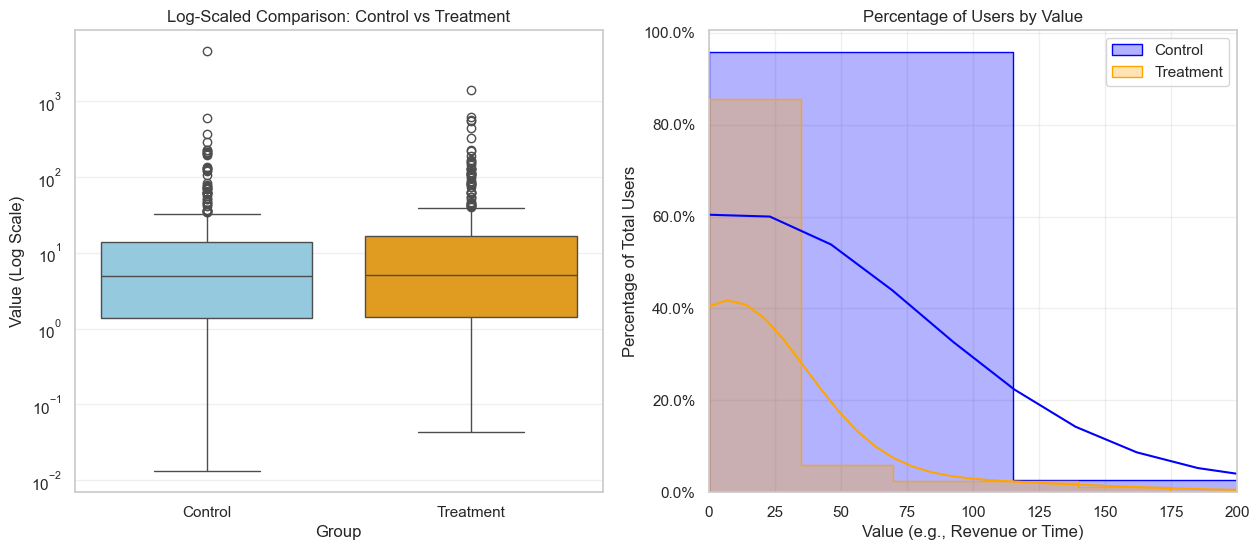

In [28]:
plt.figure(figsize=(15,6))

# boxplot
plt.subplot(1,2,1)
ax = sns.boxplot(df, x='Group', y='Value', palette=['skyblue', 'orange'])

ax.set_yscale("log")

plt.title("Log-Scaled Comparison: Control vs Treatment")
plt.ylabel("Value (Log Scale)")
plt.grid(axis='y', alpha=0.3)

# histogram

plt.subplot(1,2,2)
sns.histplot(Control, label='Control', color='blue', alpha=.3, stat="probability", kde=True, element="step")
sns.histplot(Treatment, label='Treatment', color='orange', alpha=.3, stat="probability", kde=True, element="step")


plt.xlim(0, 200)
plt.title("Percentage of Users by Value")
plt.xlabel("Value (e.g., Revenue or Time)")
plt.ylabel("Percentage of Total Users")
plt.grid(alpha=0.3)

# Now the % formatter actually makes physical sense!
plt.gca().yaxis.set_major_formatter('{:.1%}'.format) 

plt.legend()
plt.show()

In [35]:
# (b) Run both Welch's t-test and Mann-Whitney U test.
# (c) Print means, medians, and p-values from both tests.

# Paired t-test (problematic for ordinal data)
_, p_t = stats.ttest_ind(Control, Treatment, equal_var=False)

# Mann-Whitney U (robust to skew)
u_stat, p_mw = stats.mannwhitneyu(Control, Treatment, alternative='less')  

print(f't-test p-value: {p_t:.4f}')
print(f'Mann-Whitney U p-value: {p_mw:.4f}')
print()
print(f'Control mean: {np.mean(Control):.1f}')
print(f'Treatment mean: {np.mean(Treatment):.1f}')
print()
print(f'Control median: {np.median(Control):.1f}')
print(f'Mann-Whitney U p-value: {np.median(Treatment):.1f}')

t-test p-value: 0.7884
Mann-Whitney U p-value: 0.2354

Control mean: 30.4
Treatment mean: 27.0

Control median: 5.0
Mann-Whitney U p-value: 5.2


# (d) Which test is more appropriate here and why? Write your answer as a markdown cell.
Mann-Whitney U test is the best choice here given the distribution is highly skewed

In [36]:
# (e) Compute rank-biserial correlation as effect size for Mann-Whitney.
n1, n2   = len(Control), len(Treatment)
r_rb     = 1 - (2 * u_stat) / (n1 * n2)
print(f'Rank-biserial correlation: {r_rb:.4f}')
print('(0=no effect, 0.1=small, 0.3=medium, 0.5=large)')

Rank-biserial correlation: 0.0295
(0=no effect, 0.1=small, 0.3=medium, 0.5=large)


---

### Q2 — Wilcoxon signed-rank on satisfaction scores

```
120 users rate their experience 1-10 before and after a new onboarding flow.
# before = np.random.choice([4,5,6,7,7,8], size=120)
# after  = np.random.choice([5,6,7,7,8,8,9], size=120)
# (a) Plot a paired dot plot or heatmap showing score changes (before vs after).
# (b) Run paired t-test AND Wilcoxon signed-rank test.
# (c) Compare p-values and interpret.
# (d) Why is a t-test inappropriate for this data? Write a 2-sentence explanation.
```


In [ ]:
# Q2: Wilcoxon signed-rank on satisfaction scores
# Chart + analysis woven together — visualize as you discover

In [54]:
# (a) Plot a paired dot plot or heatmap showing score changes (before vs after).

before = np.random.choice([4,5,6,7,7,8], size=120)
after  = np.random.choice([5,6,7,7,8,8,9], size=120)

# setup data

df = pd.DataFrame({
    'group': ['before']*120 + ['after']*120,
    'cores': np.concatenate([before,after])

})

heatmap_data = pd.crosstab(df['group'], df['cores'])
heatmap_data

cores,4,5,6,7,8,9
group,,,,,,
after,0,12,22,32,37,17
before,16,32,12,39,21,0


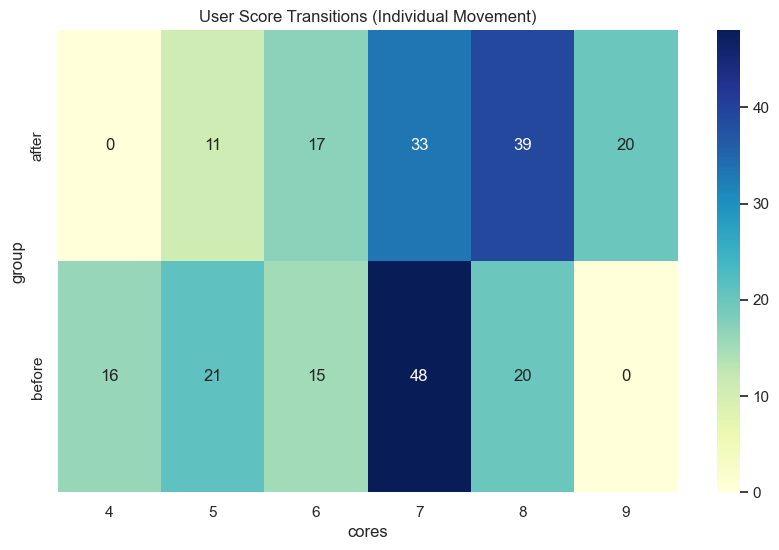

In [112]:
# plotting

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu')
plt.title("User Score Transitions (Individual Movement)")
plt.show()

In [ ]:
# (b) Run paired t-test AND Wilcoxon signed-rank test.

# Paired t-test (problematic for ordinal data)
_, p_t = stats.ttest_rel(before, after, alternative='less')

# Wilcoxon signed-rank (correct for ordinal paired data)
stat, p_w = stats.wilcoxon(before, after, alternative='less')

print(f'Before median: {np.median(before):.1f}')
print(f'After median: {np.median(after):.1f}')
print()
print(f'Paired t test p-value: {p_t:.5f}')
print(f'Wilcoxon rank test p-value: {p_w:.5f}')

Before median: 6.5
After median: 7.0

Paired t test p-value: 0.00000
Wilcoxon rank test p-value: 0.00000


# (c) Compare p-values and interpret.
Both the Paired T-test (p < 0.00001) and the Wilcoxon Signed-Rank test (p < 0.00001) indicate a significant increase in user satisfaction.

# (d) Why is a t-test inappropriate for this data? Write a 2-sentence explanation.
Given the ordinal nature of 1-10 scores, we prioritize the Wilcoxon results as they do not assume a normal distribution or equal intervals between score points.

---

### Q3 — Permutation test from scratch

```
Control:   [2.1, 3.4, 1.8, 5.2, 2.9, 4.1, 3.3, 2.7, 4.8, 1.5]
# Treatment: [3.8, 4.9, 3.1, 6.0, 4.5, 5.2, 4.8, 3.9, 5.5, 4.1]
# (a) Compute observed difference in MEDIANS (not means).
# (b) Build a permutation test with 10,000 shuffles. Use median difference as test statistic.
# (c) Plot the null distribution of permuted differences as a histogram.
#     Mark the observed difference and shade the p-value region.
# (d) Compute two-tailed p-value.
# (e) Why is the permutation test more appropriate than t-test for this small sample?
```


In [ ]:
# Q3: Permutation test from scratch
# Chart + analysis woven together — visualize as you discover

Control:   [2.1, 3.4, 1.8, 5.2, 2.9, 4.1, 3.3, 2.7, 4.8, 1.5]
# Treatment: [3.8, 4.9, 3.1, 6.0, 4.5, 5.2, 4.8, 3.9, 5.5, 4.1]
# (a) Compute observed difference in MEDIANS (not means).
# (b) Build a permutation test with 10,000 shuffles. Use median difference as test statistic.
# (c) Plot the null distribution of permuted differences as a histogram.
#     Mark the observed difference and shade the p-value region.
# (d) Compute two-tailed p-value.
# (e) Why is the permutation test more appropriate than t-test for this small sample?

In [76]:
# (a) Compute observed difference in MEDIANS (not means).
np.random.seed(42)

control = [2.1, 3.4, 1.8, 5.2, 2.9, 4.1, 3.3, 2.7, 4.8, 1.5]
treatment = [3.8, 4.9, 3.1, 6.0, 4.5, 5.2, 4.8, 3.9, 5.5, 4.1]

observed_diff = np.median(treatment) - np.median(control)
print(f'Observed median difference: {observed_diff:.3f}')

Observed median difference: 1.550


In [92]:
# (b) Build a permutation test with 10,000 shuffles. Use median difference as test statistic.
np.random.seed(42)

combined  = np.concatenate([control, treatment])
n_control = len(control)
n_perms   = 10000
print(combined, n_control)

perm_diffs = np.array([
    np.median(np.random.permutation(combined)[:n_control]) -
    np.median(np.random.permutation(combined)[n_control:])
    for _ in range(n_perms)
])

print(perm_diffs)

[2.1 3.4 1.8 5.2 2.9 4.1 3.3 2.7 4.8 1.5 3.8 4.9 3.1 6.  4.5 5.2 4.8 3.9
 5.5 4.1] 10
[ 0.95 -0.85 -0.75 ...  1.15  0.1  -0.1 ]


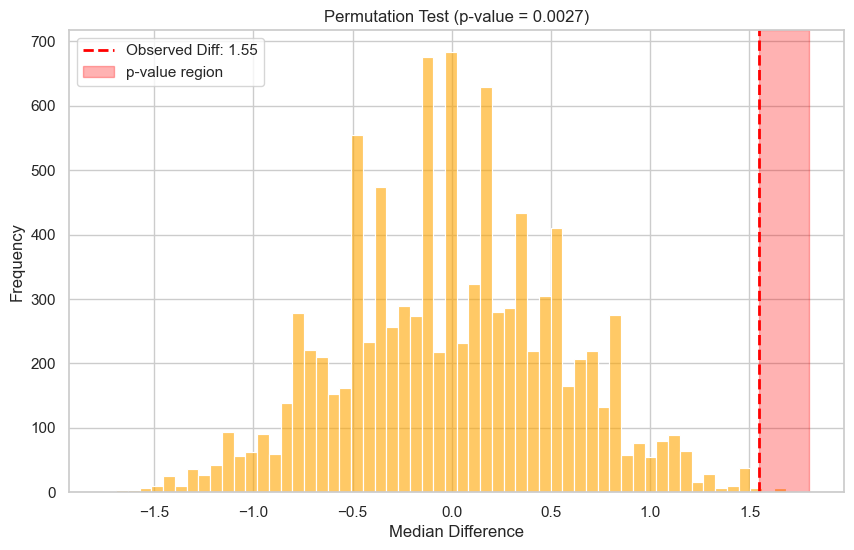

In [114]:
# (c) Plot the null distribution of permuted differences as a histogram.
#     Mark the observed difference and shade the p-value region.

plt.figure(figsize=(10,6))
sns.histplot(perm_diffs, bins=60, alpha=0.6, color='orange')

plt.axvline(observed_diff, color='red', lw=2, linestyle='--', label=f'Observed Diff: {observed_diff:.2f}')

plt.axvspan(observed_diff, perm_diffs.max(), alpha=0.3, color='red', label='p-value region')

plt.title(f'Permutation Test (p-value = {p_perm:.4f})')
plt.xlabel('Median Difference')
plt.ylabel('Frequency')
plt.legend()

plt.show()

In [90]:
# (d) Compute two-tailed p-value.
p_perm = (np.abs(perm_diffs) >= np.abs(observed_diff)).mean()
print(f'Permutation test p-value: {p_perm:.4f}')

Permutation test p-value: 0.0029


# (e) Why is the permutation test more appropriate than t-test for this small sample?

Permutation tests work for ANY statistic — mean, median, 90th percentile, custom business metric — without assumptions.

---

### Q4 — Parametric vs non-parametric decision framework

```
You are given 5 scenarios. For each one: decide parametric or non-parametric, name the specific test, and justify.
# Scenario 1: Email open rates, n=50,000 per group
# Scenario 2: Time to first purchase, n=80 per group, very right-skewed
# Scenario 3: NPS score (-100 to 100), n=200 per group
# Scenario 4: Page load time in ms, n=500 per group, bimodal distribution
# Scenario 5: Same users completing a task, measured before and after a UI change, n=45
```


In [ ]:
# Q4: Parametric vs non-parametric decision framework

```
# Scenario 1: Email open rates, n=50,000 per group 
-> Two-proportion z-test (parametric) because the measure metric is a binary outcome and the sample size is sizeable

# Scenario 2: Time to first purchase, n=80 per group, very right-skewed
-> Mann-Whitney U (non-parametric) test is a good choice for a very skewed data even though sample size = 80 is not small

# Scenario 3: NPS score (-100 to 100), n=200 per group
-> Mann-Whitney U (non-parametric) test is always a go-to for ordinal data

# Scenario 4: Page load time in ms, n=500 per group, bimodal distribution
-> Permutation Test (non-parametric) is the best bet since it does not care about the shape of the distribution 

# Scenario 5: Same users completing a task, measured before and after a UI change, n=45
-> A paired t-test could be a good option but Wilcoxin signed-rank also offers a decent plan B
```